## Imports and utilitaries

Run all cells in this section before simulating.


In [2]:
import os
import pandas as pd
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib.lines as lines
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch

viridis = mpl.cm.viridis
viridis_r = mpl.cm.viridis_r
norm = mpl.colors.Normalize(vmin=5, vmax=10)

### Data structures and objects

`id` is a number between 0 and 1023, referencing one of the 1024 possible joint actions of the players and the id'th line of a payoff matrix.

`strategy` is an array of size 10, where `strategy[i]` indicates the route choice of player `i`.

`coalition` is an array, containing a subset of [0..9].

In [3]:
def id_to_strategy(id):
    '''
    INPUT :`id`= integer from`[0,1023]`

    OUTPUT :`strategy`= array of size 10, binary representation of number`id`
    '''
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy


In [4]:
def strategy_to_id(s):
    '''
    INPUT :`strategy`= array of size 10, binary representation of number`id`

    OUTPUT :`id`= integer within`[0,1023]`
    '''
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id


In [5]:
def coalition_to_strategy(coalition):
    '''
    INPUT :`coalition`= subset of [0,9]

    OUTPUT :`strategy`= array of size 10,`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s


In [6]:
def strategy_to_coalition(s):
    '''
    INPUT :`strategy`= array of size 10
    
    OUTPUT :`coalition`= subset of [0,9],`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition


In [7]:
def neighbouring_strategies(s):

    '''
    INPUT :`s`= array of size n, describing the joint actions of the 10 AVs (route 0 or 1) \\
    OUTPUT : array of all 10 joint actions, each one with one of the AVs deviating from`s`
    '''

    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh


In [8]:
def neighbouring_ids(id):
    
    '''
    goes from the space of ids (integers in`0..1023`) to strategies, then to neighbouring strategies (see`neighbouring_strategies()`), and back to ids.
    '''

    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh


### Building reward tables

Functions to build a 10x1024 payoff matrix from a given experiment record or from custom dynamic traffic light parameters, and access it through the objects.

In [9]:
def build_rewardtable(file_name):

    '''
    Returns the payoff matrix from an experiment (stored in the file given as input) as an array.

    !! Will crash if the file does not exist.
    '''

    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab


In [10]:
def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    '''
    `tl_list`is an array of size 11. For each i in [0...10],`tl_list[i]`is a tuple`(tl_0,tl_1,tl_y,nb_agents)`, representing specific parameters of a network with static traffic lights.

    `custom_df`builds the payoff matrix of a network with dynamic traffic lights, where whenever n AVs choose route 1, traffic lights are set to`tl_list[n]`
    '''

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [11]:
def reward(i,id):
    return float(tab_reward[i][id])


In [12]:
def id_to_reward(id):
    return [reward(i,id) for i in range(10)]


In [13]:
def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)


In [14]:
def travel_times(id):
    s = id_to_strategy(id)
    t0 = 0
    t1 = 0
    n0 = 0
    n1 = 0
    les_t = tab_reward[:,id]
    for i in range(10):
        if s[i] == 0:
            n0 += 1
            t0 += les_t[i]
        else:
            n1 += 1
            t1 += les_t[i]
    if n0 > 0:
        t0 = t0/n0
    if n1 > 0:
        t1 = t1/n1
    return n0, n1, -t0, -t1


In [15]:
def normalized_travel_times(id,p0):
    s = id_to_strategy(id)
    t0 = 0
    t1 = 0
    n0 = 0
    n1 = 0
    les_t = tab_reward[:,id]
    for i in range(10):
        if s[i] == 0:
            n0 += 1
            t0 += les_t[i]/p0[i]
        else:
            n1 += 1
            t1 += les_t[i]/p0[i]
    if n0 > 0:
        t0 = t0/n0
    if n1 > 0:
        t1 = t1/n1
    return n0, n1, t0, t1

### Algorithms for Nash and strong equilibria

In [16]:
def nash_deviation(s):
    
    '''
    for a given strategy/joint action`s`, returns an array of size 10`dev`.

    For i in 0..9,`dev[i]`is what the AV number i can gain by deviating ALONE from`s`.
    '''

    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev


In [17]:
def nash_equilibrium(s):
    
    '''
    runs`nash_deviation(s)`, verifies if any AV can gain by deviating from`s`, and answers whether`s`is a Nash equilibrium.
    '''

    dev = nash_deviation(s)
    for i in range(10):
        if dev[i] > 0:
            return False
    return True


In [18]:
def strong_nash_equilibrium(s,verbose=True):
    
    '''
    verifies that no subset (aka coalition) of the set of AVs can deviate from`s`. \\
    A coalition deviates if every member increases its payoff when the whole coalition deviates.\\
    Add `verbose=False` if you do not want to print coalitions eligible for a deviation.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    if verbose:
        for c in list_c:
            print(c)
    return len(list_c) == 0


In [19]:
def individual_deviations(s):
    
    '''
    runs`nash_deviation(s)`, and returns the list of AVs that can gain by deviating from`s`.
    '''

    dev = nash_deviation(s)
    list_i = []
    for i in range(10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            list_i.append(i)
    return list_i

In [20]:
def coalition_deviations(s):
    
    '''
    Returns coalitions that may deviate from `s`.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    return list_c

In [21]:
def plot_deviation(club,p0):

    '''
    Input : `club` is a subset of the set of players.
    Output : `y` is the reward of all players if the club goes to route 1 and all other players go to route 0. \\
            `y_dev` is the reward of each player if they deviate alone from this situation.
    '''

    s = coalition_to_strategy(club)
    print("#######################\nClub is %s.\tJoint action is %s"%(club,s))
    print("List of agents that could deviate individually: \t",individual_deviations(s))
    print("List of coalitions that could deviate simultaneously: \t",coalition_deviations(s))
    print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s,verbose=False)))
    p = s_to_reward(s)
    nash_dev = nash_deviation(s)
    y = [p[i]/p0[i] for i in range(len(p))]
    dev = [nash_dev[i]/p0[i] for i in range(10)]
    return y,dev,s

### Define parameters

Since this file is only used to plot results from one network, let's set the parameters once and for all.

In [22]:
# Define system parameters
nb_agents = 15      # number of human + AV agents in the network
threshold = 3       # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5            # length of each yellow light phase
cycle_length = 50   # total length of the traffic light cycle

tl_0_below_threshold = 21   # how long the green light lasts on route 0 before traffic lights adapt
tl_0_above_threshold = 9    # how long the green light lasts on route 0 after traffic lights adapt
# and idem on route 1:
tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold

# payoff matrix
tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")

# Calculating deviations from the initial situation
s_0 = id_to_strategy(0)
print("#######################\nInitial situation: everyone on route 0.")
print("List of clubs that may form from x^0: \t",coalition_deviations(s_0))
print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))
p_0 = s_to_reward(s_0)
nash_dev = nash_deviation(s_0)

#######################
Initial situation: everyone on route 0.
List of clubs that may form from x^0: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False


## Testing scripts, sample code

In [30]:
print("Nash equilbrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))

Nash equilbrium: True, strong equilibrium: False


#######################
Club is [].	Joint action is [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [1, 5, 6].	Joint action is [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 [0, 7]
List of coalitions that could deviate simultaneously: 	 [[7], [0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [0, 1, 5, 6].	Joint action is [1, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 []
Nash equilibrium: True, strong equilibrium: True
#######################
Club is [1, 5, 6, 7].	Joint action is [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [0]
List of coalitions that could deviate simultaneously: 	 [[0], [0, 4]]
Na

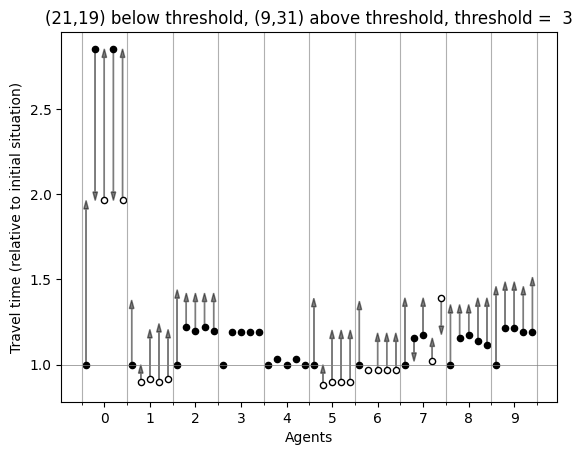

In [23]:
# Preparing the plot
les_x = [i for i in range(10)]
plt.style.use("default")
# plt.style.use('science')
fig, ax = plt.subplots()
ax.set_xticks([i - 0.5 for i in range(11)], minor=True)
ax.set_xticks([i  for i in range(10)], minor=False)
ax.set_yticks([0,0.5,1,1.5,2,2.5], minor = False)
ax.set_yticks([1], minor = True)
plt.grid(which="minor")
ax.axhline(1, color='gray', linewidth=0.5)

def plot_clubs(club,shift):
    '''
    Computes payoffs and deviations from the joint action where `club` is on route 1 and everyone else on route 0. \\
    Then, plots the results. Use `shift` to display several results side by side without overlapping.
    '''
    les_y,les_dev,s = plot_deviation(club,p_0)
    for i in range(10):
        ax.arrow(i+shift,les_y[i],0,les_dev[i],head_width = 0.1, head_length = min(0.05,np.abs(les_dev[i])),length_includes_head = True,color='0',alpha=0.5)
        ax.scatter(i+shift,les_y[i],color=str(s[i]),edgecolor='0',sizes=[20])
        # ax.plot([i + shift,i + shift],les_yplusdev[i],color=color,alpha=0.5)

plot_clubs([],-0.4)
plot_clubs([1,5,6],-0.2)
plot_clubs([0,1,5,6],0)
plot_clubs([1,5,6,7],0.2)
plot_clubs([0,1,5,6,7],0.4)

ax.set_xlabel("Agents")
ax.set_ylabel("Travel time (relative to initial situation)")
plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
plt.show()

<>:84: SyntaxWarning: invalid escape sequence '\i'
<>:85: SyntaxWarning: invalid escape sequence '\i'
<>:84: SyntaxWarning: invalid escape sequence '\i'
<>:85: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1723205959.py:84: SyntaxWarning: invalid escape sequence '\i'
  plt.savefig("..\imgs\deviations.png")
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1723205959.py:85: SyntaxWarning: invalid escape sequence '\i'
  plt.savefig("..\imgs\deviations.svg")


#######################
Club is [].	Joint action is [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
List of agents that could deviate individually: 	 []
List of coalitions that could deviate simultaneously: 	 [[1, 5, 6]]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [1, 5, 6].	Joint action is [0, 1, 0, 0, 0, 1, 1, 0, 0, 0]
List of agents that could deviate individually: 	 [0, 7]
List of coalitions that could deviate simultaneously: 	 [[7], [0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [1, 5, 6, 7].	Joint action is [0, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [0]
List of coalitions that could deviate simultaneously: 	 [[0], [0, 4]]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [0, 1, 5, 6, 7].	Joint action is [1, 1, 0, 0, 0, 1, 1, 1, 0, 0]
List of agents that could deviate individually: 	 [7]
List of coalitions that could deviate simultaneously: 	

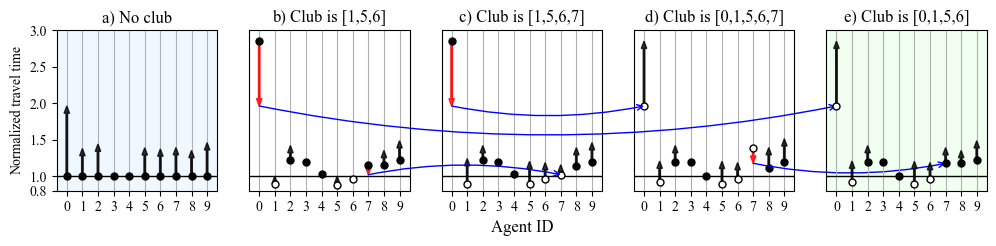

In [100]:
# Preparing the plot
les_x = [i for i in range(10)]
plt.style.use("default")
tnrfont = {'fontname':'Times New Roman'}
# plt.style.use('science')
fig = plt.figure()
fig.set_size_inches(12,3)
list_clubs = [[],[1,5,6],[1,5,6,7],[0,1,5,6,7],[0,1,5,6]]
nb_clubs_tested = len(list_clubs)
les_ax = []

les_xy = []

def plot_clubs(club,shift):
    '''
    Computes payoffs and deviations from the joint action where `club` is on route 1 and everyone else on route 0. \\
    Then, plots the results. Use `shift` to display several results side by side without overlapping.
    '''
    les_y,les_dev,s = plot_deviation(club,p_0)
    for i in range(10):
        color = '0'
        if les_dev[i] < 0:
            color = 'r'
            les_xy.append((les_x[i],les_y[i] + les_dev[i]))
        les_ax[-1].arrow(i+shift,les_y[i],0,les_dev[i],width=0.1,head_width = 0.35, head_length = min(0.1,np.abs(les_dev[i])),length_includes_head = True,color=color,zorder=2,alpha = 0.8)
        if s[i] == 0:
            les_ax[-1].plot(i+shift,les_y[i],"o",markerfacecolor='0',markeredgecolor='0',markersize=5,zorder=3)
        else:
            les_ax[-1].plot(i+shift,les_y[i],"o",markerfacecolor='1',markeredgecolor='0',markersize=5,zorder=3)
        plt.draw()
        # ax.plot([i + shift,i + shift],les_yplusdev[i],color=color,alpha=0.5)

for n in range(nb_clubs_tested):
    club = list_clubs[n]
    les_ax.append(fig.add_subplot(1,nb_clubs_tested,n+1))
    les_ax[-1].set_ylim(0.8,3)
    les_ax[-1].set_xticks([i  for i in range(10)], minor=False, )
    les_ax[-1].set_yticks([0.8,1,1.5,2,2.5,3], minor = False)
    les_ax[-1].set_xticklabels(les_ax[-1].get_xticks(), **tnrfont)
    les_ax[-1].set_yticklabels(les_ax[-1].get_yticks(), **tnrfont)
    les_ax[-1].grid(axis="x",which="major",zorder=0)
    les_ax[-1].axhline(1, color='0', linewidth=1)
    title = "Club is %s"%(club) if n > 0 else "No club"
    les_ax[-1].set_title(title,**tnrfont)
    les_ax[-1].set_box_aspect(1)
    plot_clubs(club,0)

    extent = les_ax[-1].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    # fig.savefig('../imgs/deviations_%s.png'%(club), bbox_inches=extent.expanded(1.37, 1.37),transparent=True)
    fig.savefig('../imgs/deviations_%s.svg'%(club), bbox_inches=extent.expanded(1.37, 1.37),transparent=True)
    les_ax[-1].yaxis.set_visible(False)

print(les_xy)
con = ConnectionPatch(xyA=les_xy[0], xyB=les_xy[0], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[1], axesB=les_ax[4], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[1], xyB=les_xy[1], connectionstyle="arc3,rad=-0.1", coordsA="data", coordsB="data",axesA=les_ax[1], axesB=les_ax[2], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[2], xyB=les_xy[2], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[2], axesB=les_ax[3], color="b",arrowstyle="->")
les_ax[4].add_artist(con)
con = ConnectionPatch(xyA=les_xy[3], xyB=les_xy[3], connectionstyle="arc3,rad=.1", coordsA="data", coordsB="data",axesA=les_ax[3], axesB=les_ax[4], color="b",arrowstyle="->")
les_ax[4].add_artist(con)

#ax1.plot(x[i],y[i],'ro',markersize=10)
#ax2.plot(x[i],y[i],'ro',markersize=10)
les_ax[0].yaxis.set_visible(True)
les_ax[0].set_ylabel("Normalized travel time",**tnrfont)
les_ax[0].set_facecolor('aliceblue')
les_ax[4].set_facecolor('honeydew')

les_ax[0].set_title("a) No club",**tnrfont,size=12)
les_ax[1].set_title("b) Club is [1,5,6]",**tnrfont,size=12)
les_ax[2].set_title("c) Club is [1,5,6,7]",**tnrfont,size=12)
les_ax[3].set_title("d) Club is [0,1,5,6,7]",**tnrfont,size=12)
les_ax[4].set_title("e) Club is [0,1,5,6]",**tnrfont,size=12)

les_ax[2].set_xlabel("Agent ID",**tnrfont,size=12)

black_dot = lines.Line2D([0], [0], color = "w", marker="o",markerfacecolor='0',markeredgecolor='0',markersize=8)
white_dot = lines.Line2D([0], [0], color = "w", marker="o",markerfacecolor='1',markeredgecolor='0',markersize=8)

# leg = plt.legend([black_dot, white_dot], ["Agent on route 0", "Agent on route 1"],loc = 'upper right')

# plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
plt.savefig("..\imgs\deviations.png")
plt.savefig("..\imgs\deviations.svg")
plt.show()

##  Find all clubs and explore their stability

In [34]:
# Calculating deviations from the initial situation
print("#######################\nInitial situation: everyone on route 0.")
c_dev = coalition_deviations(s_0)
print("List of clubs that may form from x^0:",c_dev)
rew_0 = s_to_reward(s_0)
print("Payoffs:",rew_0)
print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_0),strong_nash_equilibrium(s_0,verbose=False)))

def explore_deviations(club,nb_tabs=1):
    s = coalition_to_strategy(club)
    print(nb_tabs*"\t"+"#######################\n"+nb_tabs*"\t"+"Club is %s."%(club))
    ind_dev = individual_deviations(s)
    print(nb_tabs*"\t"+"List of agents that could deviate individually: %s"%ind_dev)
    new_c_dev = []
    for new_c in coalition_deviations(s):
        outofclub = True
        for i in new_c:
            if i in club:
                outofclub = False
        if outofclub:
            new_c_dev.append(new_c)
    print(nb_tabs*"\t"+"List of coalitions that could deviate simultaneously: %s"%new_c_dev)

    rew = s_to_reward(s)
    print(nb_tabs*"\t"+"Payoffs: %s"%rew)
    print(nb_tabs*"\t"+"Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s,verbose=False)))

    # checking club internal stability (nobody wants to quit)
    internal_stability = True
    for i in club:
        if i in ind_dev:
            internal_stability = False
    if not internal_stability:
        print(nb_tabs*"\t"+"Club is not internally stable (at least one member of the club wants to deviate)")
    
    for i in club:
        print(nb_tabs*"\t"+"%s gains %s from being in the club"%(i,rew[i] - rew_0[i]))
    for new_c in new_c_dev:
        explore_deviations(club + new_c,nb_tabs+1)
    
    return None

for c in c_dev:
    explore_deviations(c)

#######################
Initial situation: everyone on route 0.
List of clubs that may form from x^0: [[1, 5, 6]]
Payoffs: [-0.45, -0.9666666666666668, -0.8333333333333334, -1.0333333333333334, -0.4833333333333333, -0.9833333333333332, -0.9833333333333332, -0.85, -0.85, -0.6166666666666667]
Nash equilibrium: True, strong equilibrium: False
	#######################
	Club is [1, 5, 6].
	List of agents that could deviate individually: [0, 7]
	List of coalitions that could deviate simultaneously: [[7], [0], [0, 4]]
	Payoffs: [-1.2833333333333334, -0.8666666666666667, -1.0166666666666666, -1.2333333333333334, -0.5, -0.8666666666666667, -0.95, -0.9833333333333332, -0.9833333333333332, -0.75]
	Nash equilibrium: False, strong equilibrium: False
	1 gains 0.10000000000000009 from being in the club
	5 gains 0.11666666666666647 from being in the club
	6 gains 0.033333333333333215 from being in the club
		#######################
		Club is [1, 5, 6, 7].
		List of agents that could deviate individual

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1720806999.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), **tnrfont)
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1720806999.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), **tnrfont)
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1720806999.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), **tnrfont)
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_25188\1720806999.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


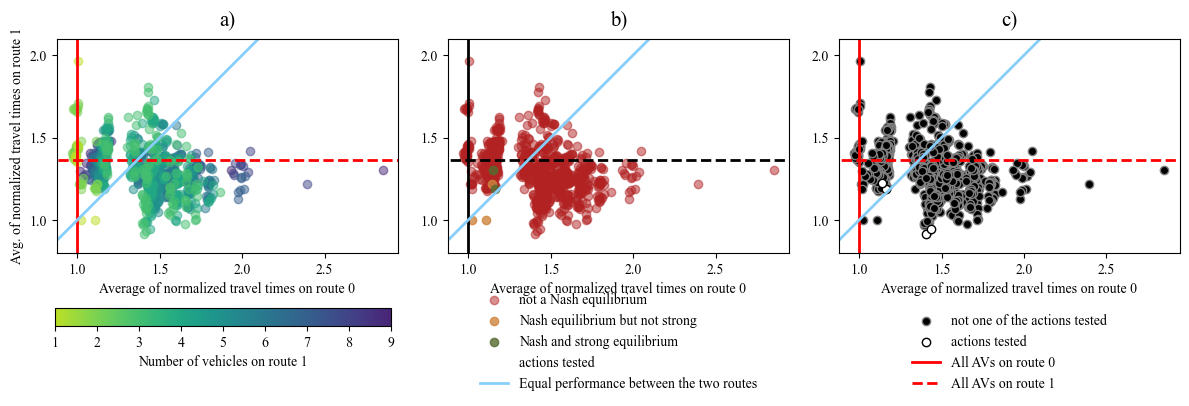

In [24]:
## Compute Nash equilibria and deviations

les_t0 = [[] for n0 in range(11)]
les_t1 = [[] for n0 in range(11)]

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

dev_x, dev_y = [], []
sdev_x, sdev_y = [], []
notdev_x, notdev_y = [], []

list_clubs = [[],[1,5,6],[1,5,6,7],[0,1,5,6,7],[0,1,5,6]]
# list_clubs = [[4,5,9]]
list_clubs_ids = [strategy_to_id(coalition_to_strategy(c)) for c in list_clubs]
clubs_x, clubs_y = [], []
notclubs_x, notclubs_y = [], []

rew = id_to_reward(0)
list_c = []

for id in range(1024):
    # n0,n1,t0,t1 = travel_times(id)
    n0,n1,t0,t1 = normalized_travel_times(id,p_0)
    les_t0[n0].append(t0)
    les_t1[n0].append(t1)

    if n0*n1 > 0: # we remove the dots (n0,n1) = (0,10) and (n0,n1) = (10,0)
        if nash_equilibrium(id_to_strategy(id)):
            if strong_nash_equilibrium(id_to_strategy(id),verbose=False):
                snash_x.append(t0)
                snash_y.append(t1)
            else:
                nash_x.append(t0)
                nash_y.append(t1)
        else:
            notnash_x.append(t0)
            notnash_y.append(t1)
    
        s = id_to_strategy(id)
        coalition = strategy_to_coalition(s)
        alt = s_to_reward(s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            if n1 == 1:
                dev_x.append(t0)
                dev_y.append(t1)
            else:
                sdev_x.append(t0)
                sdev_y.append(t1)
        else:
            notdev_x.append(t0)
            notdev_y.append(t1)
        
        if id in list_clubs_ids:
            clubs_x.append(t0)
            clubs_y.append(t1)
        else:
            notclubs_x.append(t0)
            notclubs_y.append(t1)

# Drawing plots

fig = plt.figure()
fig.set_size_inches(12,6)
tnrfont = {'fontname':'Times New Roman'}

## Drawing the first plot (colors depend on the flow on each route)

ax = fig.add_subplot(1,3,1)

for n0 in range(1,10):
    ax.scatter(les_t0[n0],les_t1[n0],label="(n0,n1) = (%s,%s)"%(n0,10-n0),alpha = 0.5,color = viridis(n0/10))

ax.set_xlabel("Average of normalized travel times on route 0", **tnrfont)
ax.set_ylabel("Avg. of normalized travel times on route 1", **tnrfont)
ax.set_yticks([i/10 for i in range(5,30,5)])
ax.set_xticklabels(ax.get_xticks(), **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "r", label="All AVs on route 0"))
ax.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "r", label="All AVs on route 1"))
ax.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance", color="lightskyblue"))

# ax.legend(prop={'family':tnrfont['fontname'], 'size':9}, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, frameon=False)

ax.set_title("a)",**tnrfont,size=15,pad=10)
ax.set_aspect("equal", adjustable="box")
ax.set_ylim([0.8,2.1])
#leg = plt.legend( loc = 'upper left')
plt.draw()

## Drawing the second plot (colors depend on the equilibrium status)

ax = fig.add_subplot(1,3,2)

ax.scatter(notnash_x,notnash_y,label="not a Nash equilibrium",alpha = 0.5,color = 'firebrick')
ax.scatter(nash_x,nash_y,label="Nash equilibrium but not strong",alpha = 0.8,color = 'peru')
ax.scatter(snash_x,snash_y,label="Nash and strong equilibrium",alpha = 0.8,color = 'darkolivegreen')
ax.scatter(clubs_x,clubs_y,label="actions tested",alpha = 0,edgecolor='0')

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "0"))
ax.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "0"))
ax.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance between the two routes", color="lightskyblue"))

ax.set_xlabel("Average of normalized travel times on route 0", **tnrfont)
# ax.set_ylabel("Average of normalized travel time on route 1", **tnrfont)
ax.set_yticks([i/10 for i in range(5,30,5)])
ax.set_xticklabels(ax.get_xticks(), **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)

norm = mpl.colors.Normalize(vmin=0, vmax=10)
sm = mpl.cm.ScalarMappable(cmap=viridis_r, norm=norm)
sm.set_array([])  # Required for ScalarMappable to work
cbar_ax = fig.add_axes([0.05,0.2, 0.28, 0.03]) 
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Value of n0')
cbar_ax.set_xlim(1,9)
cbar_ax.set_xticks([1,2,3,4,5,6,7,8,9])
cbar_ax.set_xticklabels([1,2,3,4,5,6,7,8,9], **tnrfont)
cbar.set_label("Number of vehicles on route 1",**tnrfont)

ax.set_aspect("equal", adjustable="box")
ax.set_ylim([0.8,2.1])
ax.legend(prop={'family':tnrfont['fontname'], 'size':10}, loc='lower center', bbox_to_anchor=(0.5,-0.7), frameon=False)
ax.set_title("b)",**tnrfont,size=15,pad=10)
# ax.set_title("Average travel times on each route.\n Each dot is a different joint action", **tnrfont)
plt.draw()

## Drawing the third plot (colors depend on how interesting the deviation is)

ax = fig.add_subplot(1,3,3)

ax.scatter(notclubs_x,notclubs_y,label="not one of the actions tested",alpha = 1,color = '0',edgecolor='0.5')
ax.scatter(clubs_x,clubs_y,label="actions tested",alpha = 1,color = '1',edgecolor='0')

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "r", label="All AVs on route 0"))
ax.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "r", label="All AVs on route 1"))
ax.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, color="lightskyblue"))

ax.set_xlabel("Average of normalized travel times on route 0", **tnrfont)
# ax.set_ylabel("Average of normalized travel times on route 1", **tnrfont)
ax.set_yticks([i/10 for i in range(5,30,5)])
ax.set_xticklabels(ax.get_xticks(), **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)

ax.set_aspect("equal", adjustable="box")
ax.set_ylim([0.8,2.1])
ax.legend(prop={'family':tnrfont['fontname'], 'size':10}, loc='lower center', bbox_to_anchor=(0.5, -0.7), frameon=False)
ax.set_title("c)",**tnrfont,size=15,pad=10)
plt.draw() 

## Update the plot
plt.tight_layout()
plt.savefig("../imgs/travel_times.png")
plt.show()

In [ ]:
## Drawing the third plot (colors depend on how interesting the deviation is)

ax = fig.add_subplot(2,2,3)

ax.scatter(notdev_x,notdev_y,label="uninteresting deviation",alpha = 0.5,color = 'r')
ax.scatter(dev_x,dev_y,label="individual deviation",alpha = 1,color = 'g')
ax.scatter(sdev_x,sdev_y,label="coalitional deviation",alpha = 1,color = 'y')

ax.set_xlabel("Average travel time on route 0", **tnrfont)
ax.set_ylabel("Average travel time on route 1", **tnrfont)
ax.set_yticks([i/10 for i in range(5,30,5)])
ax.set_xticklabels(ax.get_xticks(), **tnrfont)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,3], linewidth=2, color = "b", label="All AVs on route 0"))
ax.add_artist(lines.Line2D([0,3],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax.add_artist(lines.Line2D([0,3], [0,3], linewidth=2, label="Equal performance"))

ax.set_aspect("equal", adjustable="datalim")
ax.set_box_aspect(1)
#leg = plt.legend( loc = 'upper right')
plt.draw() 

## Single actions

In [107]:
list = ["alltraveltimes_noclub.csv","alltraveltimes_club_1_5_6.csv","alltraveltimes_club_1_5_6_7.csv","alltraveltimes_club_0_1_5_6_7.csv","alltraveltimes_club_0_1_5_6.csv"]

def filter(tab, column, kind):
    return tab[tab[column] == kind]

df_x0 = pd.read_csv("alltraveltimes_noclub.csv")[["travel_time","action","kind"]]

AVG = []
HDV = []
CDV = []
R0 = []
R1 = []

for filename in list:
    df = pd.read_csv(filename)[["travel_time","action","kind"]]
    df["normalized_traveltime"] = df["travel_time"]/df_x0["travel_time"]
    dfCDV,dfHDV = filter(df,"kind","AV"), filter(df,"kind","Human")
    dfR0,dfR1 = filter(df,"action",0), filter(df,"action",1)

    AVG.append(df["normalized_traveltime"].mean())
    HDV.append(dfHDV["normalized_traveltime"].mean())
    CDV.append(dfCDV["normalized_traveltime"].mean())
    R0.append(dfR0["normalized_traveltime"].mean())
    R1.append(dfR1["normalized_traveltime"].mean())

    print(df["normalized_traveltime"].mean(), dfHDV["normalized_traveltime"].mean(), dfCDV["normalized_traveltime"].mean())
    print(df["normalized_traveltime"].mean(), dfR0["normalized_traveltime"].mean(), dfR1["normalized_traveltime"].mean())
    print()

1.0 1.0 1.0
1.0 1.0 nan

1.2733682313313355 1.305337882946369 1.2573834055238184
1.2733682313313355 1.3630428432261212 0.9146697837521917

1.2622388566924891 1.305337882946369 1.2406893435655493
1.2622388566924891 1.377546954859194 0.9451415867340507

1.2229333544023826 1.302059194421779 1.1833704343926847
1.2229333544023826 1.2210680607218387 1.2266639417634706

1.2142776398643151 1.302059194421779 1.1703868625855836
1.2142776398643151 1.2248183410811337 1.185290711518064



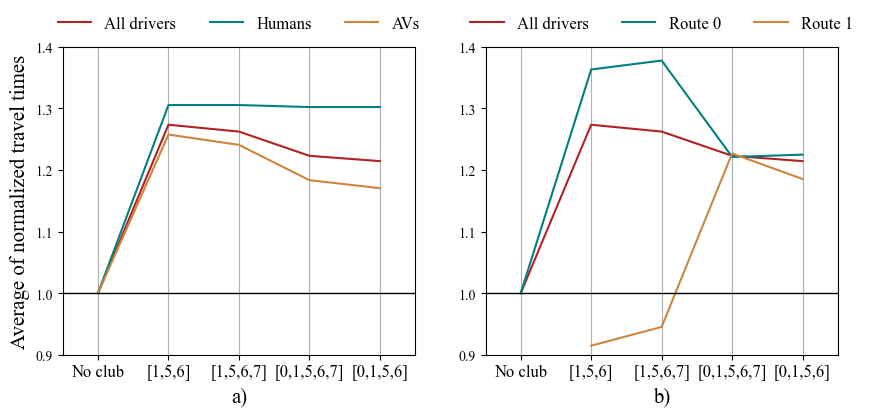

In [98]:
fig = plt.figure()
fig.set_size_inches(10,4)
colors = ["firebrick", "teal", "peru", "navy", "salmon", "slategray", "darkviolet", "lightskyblue", "darkolivegreen", "black"]
tnrfont = {'fontname':'Times New Roman'}

## 1st plot

ax = fig.add_subplot(121)
ax.plot([1,2,3,4,5],AVG, label = "All drivers", color=colors[0])
ax.plot([1,2,3,4,5],HDV, label = "Humans", color=colors[1])
ax.plot([1,2,3,4,5],CDV, label = "AVs", color=colors[2])

ax.set_xticks([1,2,3,4,5])
ax.set_xlim(0.5,5.5)
ax.set_yticks([0.9,1,1.1,1.2,1.3,1.4])
ax.set_ylim(0.9,1.4)
ax.axhline(1, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)
ax.set_xlabel("a)", **tnrfont, size=15)
ax.set_ylabel("Average of normalized travel times", **tnrfont,size=15)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, frameon=False)

## 2nd plot

ax = fig.add_subplot(122)
ax.plot([1,2,3,4,5],AVG, label = "All drivers", color=colors[0])
ax.plot([1,2,3,4,5],R0, label = "Route 0", color=colors[1])
ax.plot([1,2,3,4,5],R1, label = "Route 1", color=colors[2])

ax.set_xticks([1,2,3,4,5])
ax.set_xlim(0.5,5.5)
ax.set_yticks([0.9,1,1.1,1.2,1.3,1.4])
ax.set_ylim(0.9,1.4)
ax.axhline(1, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont)
ax.set_xlabel("b)", **tnrfont, size=15)
# ax.set_ylabel("Average of normalized travel times", **tnrfont)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3, frameon=False)

plt.savefig("../imgs/average_travel_times.png")
plt.savefig("../imgs/average_travel_times.svg")
plt.show()


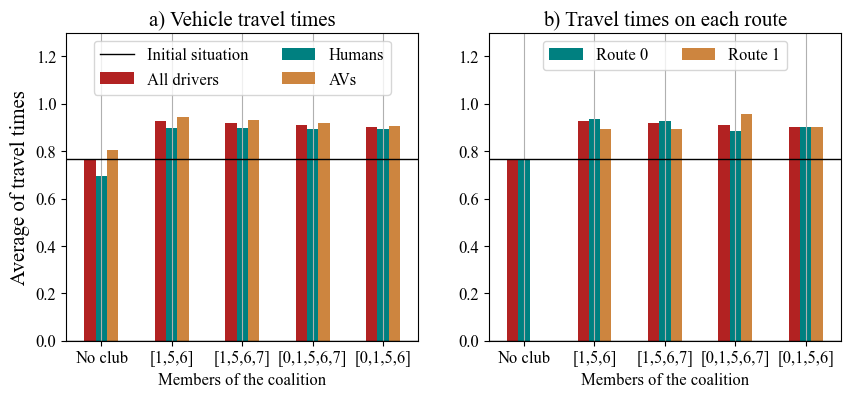

In [ ]:
fig = plt.figure()
fig.set_size_inches(10,4)
colors = ["firebrick", "teal", "peru", "navy", "salmon", "slategray", "darkviolet", "lightskyblue", "darkolivegreen", "black"]
tnrfont = {'fontname':'Times New Roman'}

width = 0.16

## 1st plot

ax = fig.add_subplot(121)
ax.bar([i - width for i in range(5)],AVG, label = "All drivers", color=colors[0],width=width)
ax.bar([i for i in range(5)],HDV, label = "Humans", color=colors[1],width=width)
ax.bar([i + width for i in range(5)],CDV, label = "AVs", color=colors[2],width=width)

ax.set_xticks([0,1,2,3,4])
ax.set_xlim(-0.5,4.5)
ax.set_ylim(0,1.3)
ax.set_yticks([0,0.2,0.4,0.6,0.8,1,1.2])
ax.axhline(AVG[0], color='0', linewidth=1, label="Initial situation")
ax.axhline(0, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont, size=12)

ax.set_xlabel("Members of the coalition", **tnrfont, size=12)
ax.set_ylabel("Average of travel times", **tnrfont,size=15)
ax.set_title("a) Vehicle travel times", **tnrfont, size=15)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='upper center', bbox_to_anchor=(0.5,1), ncol=2, frameon=True)

## 2nd plot

ax = fig.add_subplot(122)
ax.bar([i - width for i in range(5)],AVG, color=colors[0],width=width)
ax.bar([i for i in range(5)],R0, label = "Route 0", color=colors[1],width=width)
ax.bar([i + width for i in range(5)],R1, label = "Route 1", color=colors[2],width=width)

ax.set_xticks([0,1,2,3,4])
ax.set_xlim(-0.5,4.5)
ax.set_yticks([0,0.2,0.4,0.6,0.8,1,1.2])
ax.set_ylim(0,1.3)
ax.axhline(AVG[0], color='0', linewidth=1)
ax.axhline(0, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club", "[1,5,6]", "[1,5,6,7]", "[0,1,5,6,7]", "[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont, size=12)
ax.set_xlabel("Members of the coalition", **tnrfont, size=12)
ax.set_title("b) Travel times on each route", **tnrfont, size=15)
# ax.set_ylabel("Average of normalized travel times", **tnrfont)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='upper center', bbox_to_anchor=(0.5,1), ncol=2, frameon=True)

plt.draw()
plt.savefig("../imgs/average_travel_times_bars.png")
plt.savefig("../imgs/average_travel_times_bars.svg")
plt.savefig("../imgs/average_travel_times_bars_transparent.png", transparent=True)
plt.savefig("../imgs/average_travel_times_bars_transparent.svg", transparent=True)
plt.show()

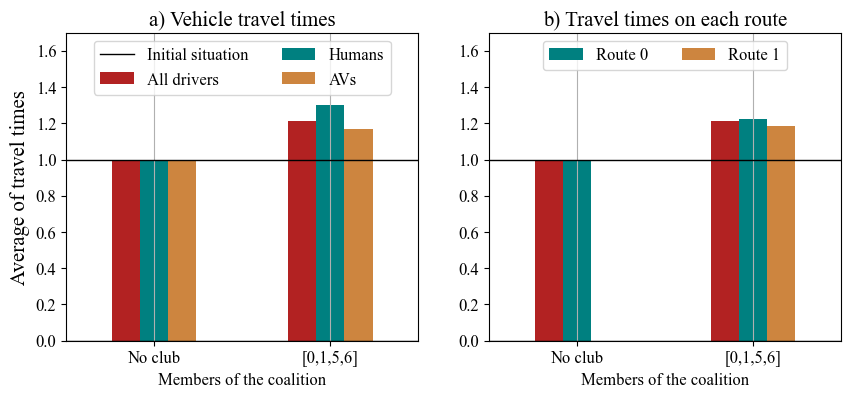

In [111]:
fig = plt.figure()
fig.set_size_inches(10,4)
colors = ["firebrick", "teal", "peru", "navy", "salmon", "slategray", "darkviolet", "lightskyblue", "darkolivegreen", "black"]
tnrfont = {'fontname':'Times New Roman'}

width = 0.16

## 1st plot

ax = fig.add_subplot(121)
ax.bar([i - width for i in range(2)],[AVG[0],AVG[4]], label = "All drivers", color=colors[0],width=width)
ax.bar([i for i in range(2)],[HDV[0],HDV[4]], label = "Humans", color=colors[1],width=width)
ax.bar([i + width for i in range(2)],[CDV[0],CDV[4]], label = "AVs", color=colors[2],width=width)

ax.set_xticks([0,1])
ax.set_xlim(-0.5,1.5)
ax.set_ylim(0,1.7)
ax.set_yticks([0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6])
ax.axhline(AVG[0], color='0', linewidth=1, label="Initial situation")
ax.axhline(0, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club","[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont, size=12)

ax.set_xlabel("Members of the coalition", **tnrfont, size=12)
ax.set_ylabel("Average of travel times", **tnrfont,size=15)
ax.set_title("a) Vehicle travel times", **tnrfont, size=15)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='upper center', bbox_to_anchor=(0.5,1), ncol=2, frameon=True)

## 2nd plot

ax = fig.add_subplot(122)
ax.bar([i - width for i in range(2)],[AVG[0],AVG[4]], color=colors[0],width=width)
ax.bar([i for i in range(2)],[R0[0],R0[4]], label = "Route 0", color=colors[1],width=width)
ax.bar([i + width for i in range(2)],[R1[0],R1[4]], label = "Route 1", color=colors[2],width=width)

ax.set_xticks([0,1])
ax.set_xlim(-0.5,1.5)
ax.set_yticks([0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6])
ax.set_ylim(0,1.7)
ax.axhline(AVG[0], color='0', linewidth=1)
ax.axhline(0, color='0', linewidth=1)
ax.grid(axis="x",which="major",zorder=0)

ax.set_xticklabels(["No club","[0,1,5,6]"], **tnrfont, size=12)
ax.set_yticklabels(ax.get_yticks(), **tnrfont, size=12)
ax.set_xlabel("Members of the coalition", **tnrfont, size=12)
ax.set_title("b) Travel times on each route", **tnrfont, size=15)
# ax.set_ylabel("Average of normalized travel times", **tnrfont)

ax.legend(prop={'family':tnrfont['fontname'], 'size':12}, loc='upper center', bbox_to_anchor=(0.5,1), ncol=2, frameon=True)

plt.draw()
plt.savefig("../imgs/average_travel_times_bars.png")
plt.savefig("../imgs/average_travel_times_bars.svg")
plt.savefig("../imgs/average_travel_times_bars_transparent.png", transparent=True)
plt.savefig("../imgs/average_travel_times_bars_transparent.svg", transparent=True)
plt.show()